In [ ]:
import marimo as mo

import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# kagglehub.login()

try: 
    path = kagglehub.competition_download('playground-series-s6e7')
except Exception as e: 
    print("Failed to download competition data. Manually download the dataset from the competitions page.")
else:
    print(f"-- Downloaded competition data to '{path}' --\n")

main_dir = "playground-series-s6e7"

try:
    train_data = pd.read_csv(f"{main_dir}/train.csv")
    test_data = pd.read_csv(f"{main_dir}/test.csv")
    sample_sub = pd.read_csv(f"{main_dir}/sample_submission.csv")
except FileNotFoundError:
    print(f"Failed to load data. Ensure that '{main_dir}' exists in your current working directory.")
else: 
    print(f"-- '{main_dir}' found. Loaded '{main_dir}' successfully --")

sns.set_theme(style="darkgrid", palette="Set2")

Failed to download competition data. Manually download the dataset from the competitions page.
-- 'playground-series-s6e7' found. Loaded 'playground-series-s6e7' successfully --


# Exploratory Data Analysis

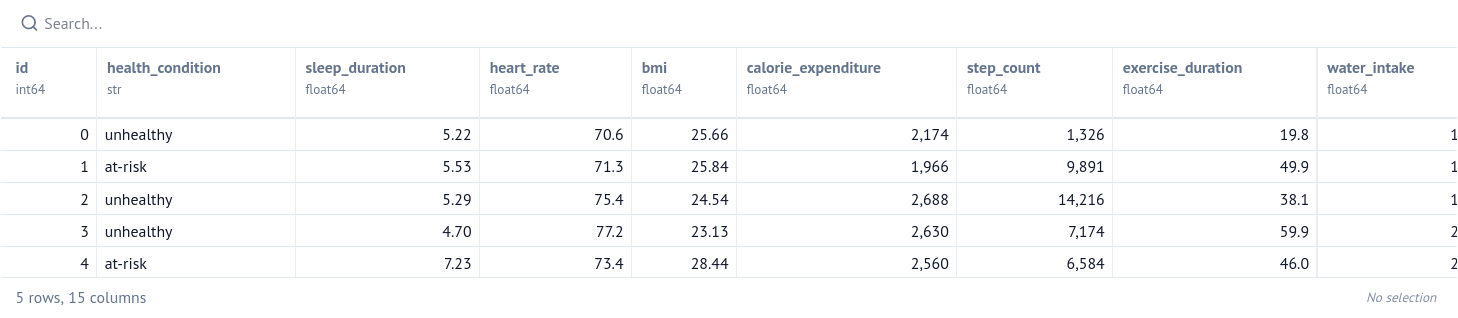

In [ ]:
train_data.head()

In [ ]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

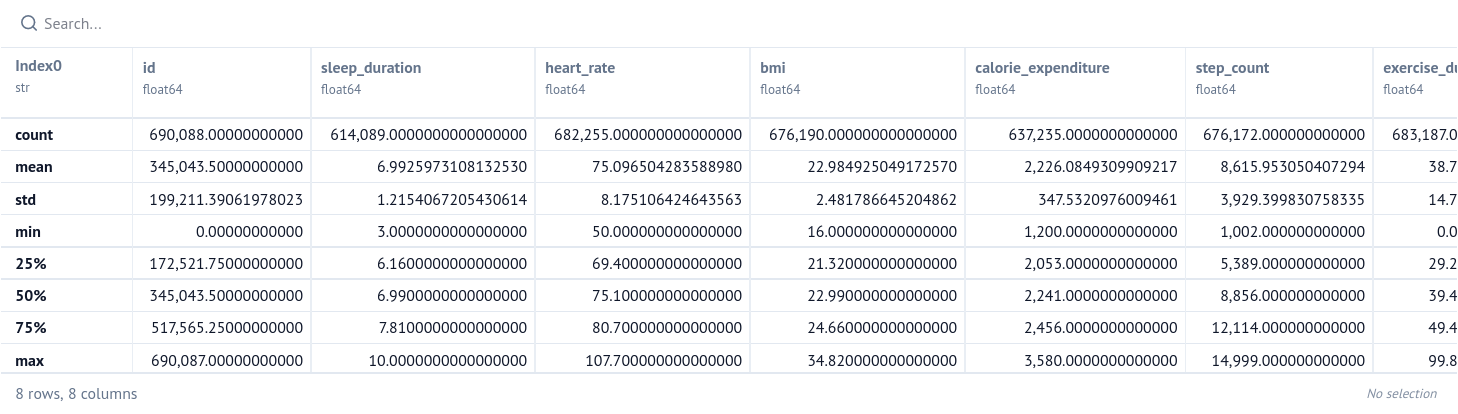

In [ ]:
train_data.describe()

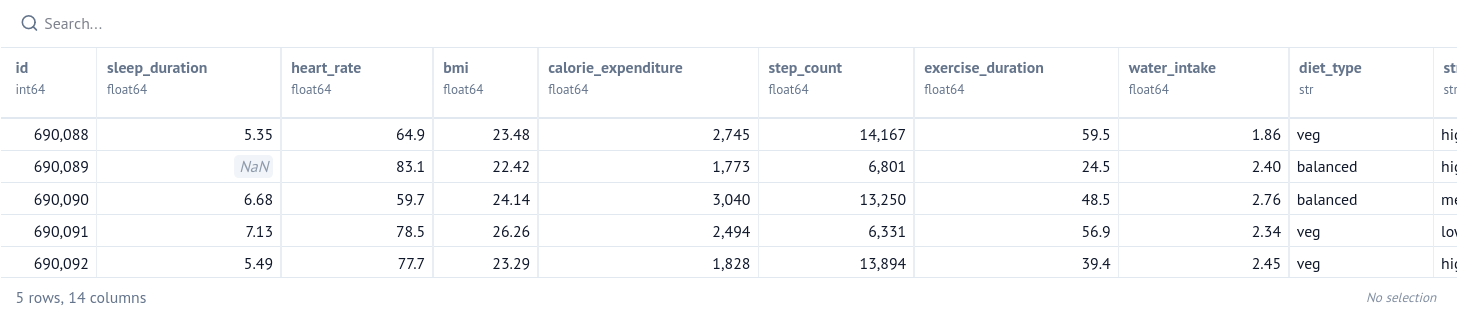

In [ ]:
test_data.head()

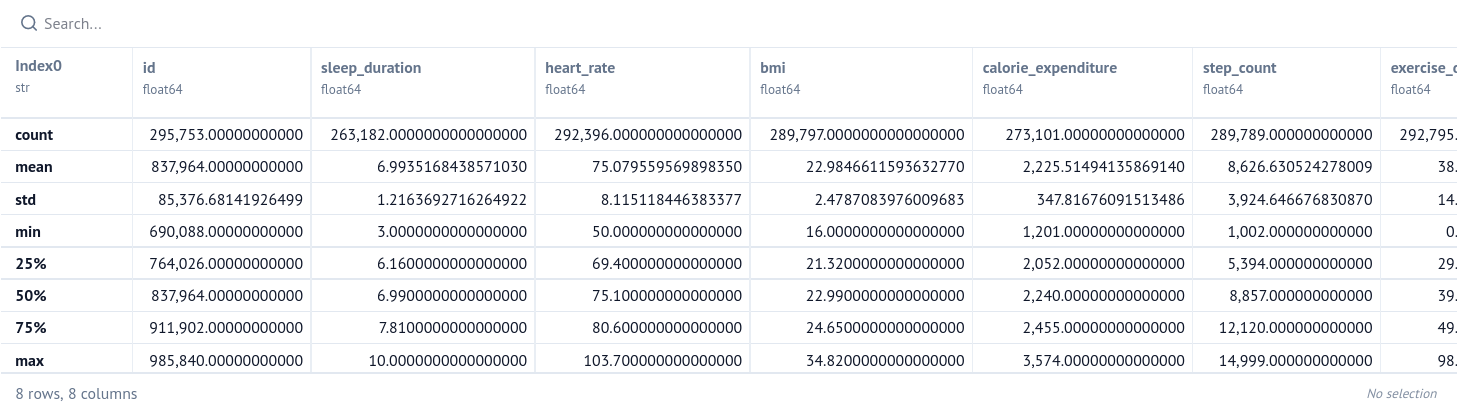

In [ ]:
test_data.describe()

In [ ]:
train_cat = train_data.select_dtypes(exclude="number")
train_num = train_data.select_dtypes(include="number")

ord_cols = ["sleep_quality", "physical_activity_level", "stress_level"]

cat_cols = []
for col in train_cat.columns.tolist():
    if col not in ord_cols:
        cat_cols.append(col)

num_cols = train_num.columns.tolist()[1:]

print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")
print(f"Ordinal Columns: ({len(ord_cols)}): {ord_cols}")
print(f"Numerical Columns ({len(num_cols)}): ", num_cols)

Categorical Columns (4): ['health_condition', 'diet_type', 'smoking_alcohol', 'gender']
Ordinal Columns: (3): ['sleep_quality', 'physical_activity_level', 'stress_level']
Numerical Columns (7):  ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


## 1. Feature information

1. **Categorical**
    - `health_condition` - Target variable. Overall health classification of the student: Fit/At-Risk/Unhealthy
    - `diet_type` - The student's general eating pattern/category (e.g., balanced, high-carb, protein, junk food, vegetarian, etc.).
    - `smoking_alcohol` - Indicates whether the student smokes and/or consumes alcohol (e.g., None, Smoking only, Alcohol only, Both).
    - `gender` - The student's gender (e.g., Male, Female, Other).

2. **Ordinal**
    - `sleep_quality` - A ranked rating of how restful/effective the student's sleep is (e.g., Poor -> Fair -> Good -> Excellent).
    - `physical_activity_level` - A ranked category of how physically active the student is overall (e.g., Sedentary -> Light -> Moderate-> Active -> Very Active).
    - `stress_level` - A ranked measure of the student's perceived stress (e.g., Low -> Moderate -> High -> Severe).

3. **Numerical**
    - `sleep_duration` - Total hours of sleep per night.
    - `heart_rate` - Resting or average heart rate in beats per minute (bpm).
    - `bmi` - Body Mass Index.
    - `calorie_expenditure` - Estimated total calories burned per day.
    - `step_count` - Number of steps take per day.
    - `exercise_duration` - Total minutes spent in dedicated exercise/workout sessions per day.
    - `water_intake` - Daily water consumption.

## 2. Target Analysis

### 2.1. Target Distribution

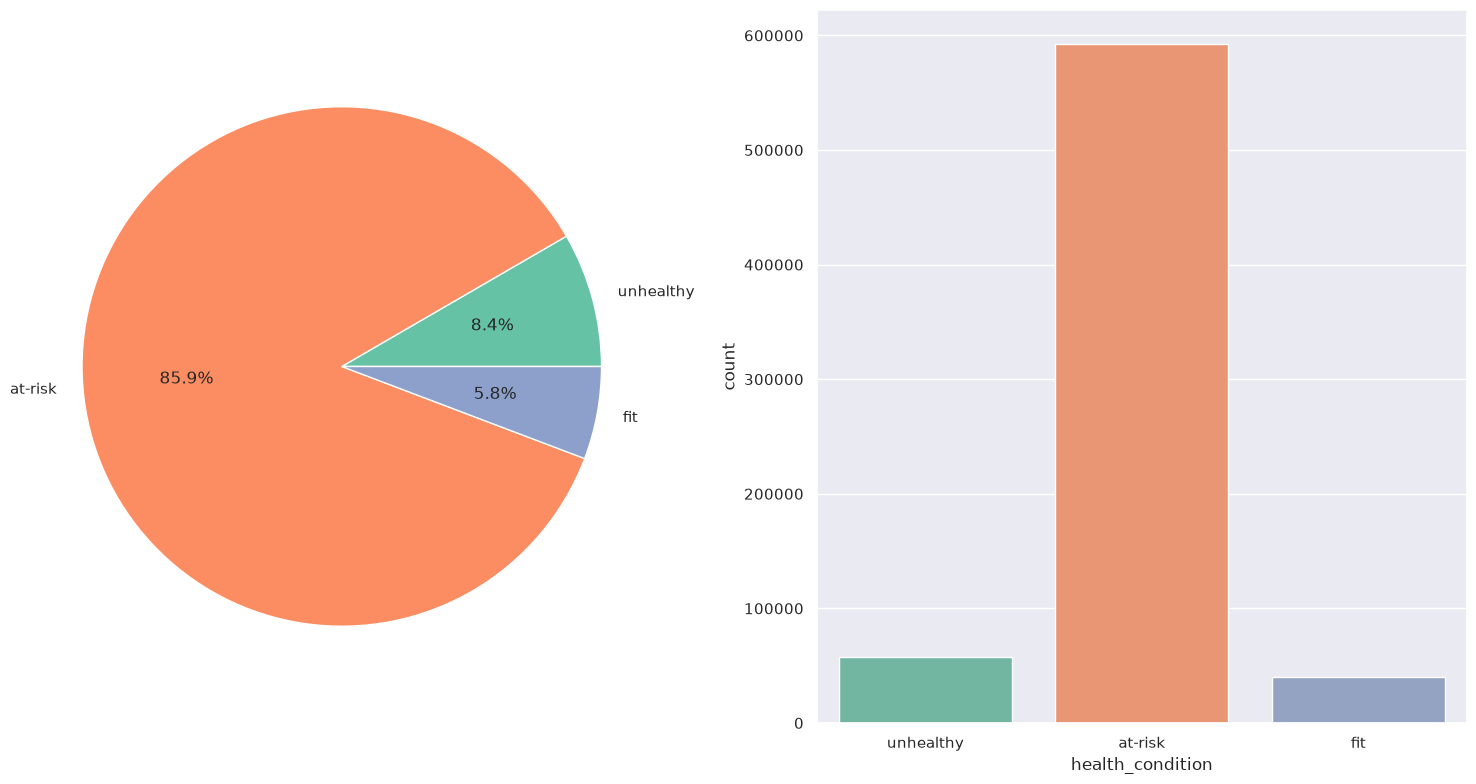

In [ ]:
classes = train_data["health_condition"].unique().tolist()
class_cnts = {cls : len(train_data[train_data["health_condition"] == cls]) for cls in classes}

fig_1, ax_1 = plt.subplots(1, 2, figsize=(15, 8))

ax_1[0].pie(x=list(class_cnts.values()), labels=list(class_cnts.keys()), autopct="%1.1f%%")
sns.countplot(data=train_data, x="health_condition", hue="health_condition", ax=ax_1[1])

fig_1.tight_layout()
plt.gca()

**Observations**: Severe class-imbalance. The `at-risk` class dominates the target with about 85.9% observations compared to the `unhealthy` and `fit` classes at 8.4% and 5.8% respectively.

### 2.2. Feature distributions by target

In [ ]:
# Create a copy of the training data with the `id` column dropped
data_no_id = train_data.drop("id", axis=1)

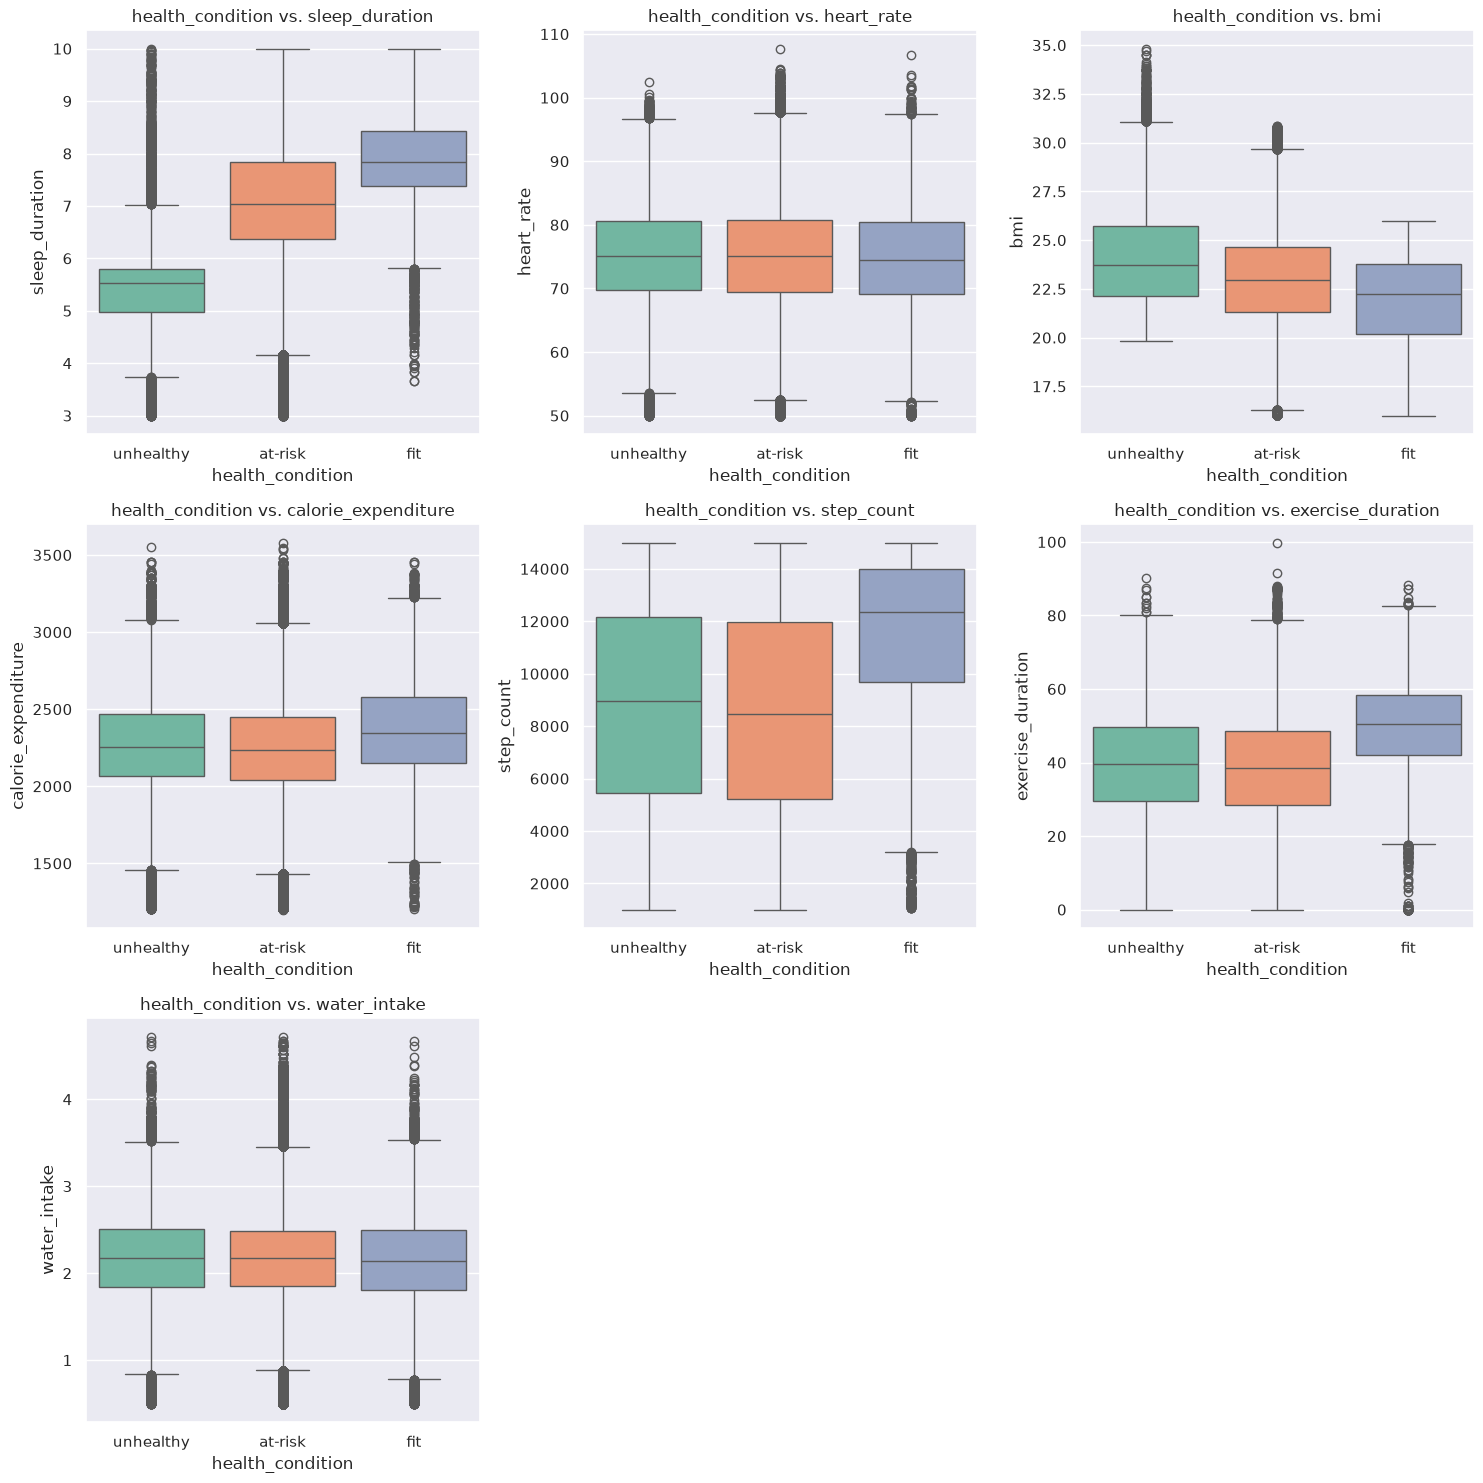

In [ ]:
def plot_distributions_by_target(
    df:pd.DataFrame, 
    target:str,
    nfeats:list[str], 
    ncols:int, 
    figsize=(15, 15)
) -> None:
    nrows = -(-len(nfeats) // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, feat in enumerate(nfeats):
        row, col = i // ncols, i % ncols 
        ax = axes[row, col] if nrows > 1 else axes[col]
        ax.set_title(f"{target} vs. {feat}")
        sns.boxplot(df, x=target, y=feat, hue=target, ax=ax)

    if len(nfeats) % ncols != 0:
        for i in range(len(nfeats) % ncols, ncols):
            axes[-1, i].axis('off')

    fig.tight_layout()

plot_distributions_by_target(train_data, "health_condition", num_cols, 3)
plt.gca()

**Observations**:

**Strong, clearly ordered relationships**:
- `sleep_duration`: Very clean separation. The boxes barely overlap.
- `step_count`: Fit stands well apart from unhealthy/at-risk, which overlap heavily with each other.
- `exercise_duration`: Similar pattern to `step_count`. Fit is clearly higher and tighter, while unhealthy and at-risk overlap substantially.
- `bmi`: Monotonic and ordered. Though the boxes overlap quite a bit more than `sleep_duration`, it is still directionally informative.

**Weak or negligible relationships**:
- `heart_rate`: The three boxes are nearly identical.
- `calorie_expenditure`: Medians and IQRs are very close across all three classes with heavy overlap.
- `water_intake`: Essentially identical distributions across all three groups.

**Fit** is the most distinct class, especially on `step_count` and `exercise_duration`. It's clearly separated from the two. **Unhealthy** vs **At-Risk** is the harder distinction since for several features (`step_count`, `calorie_expenditure`, `heart_rate`) their boxes overlap almost completely. This suggests that the model may struggle most to distinguish these two classes from each other.

### 2.3. Target Correlation

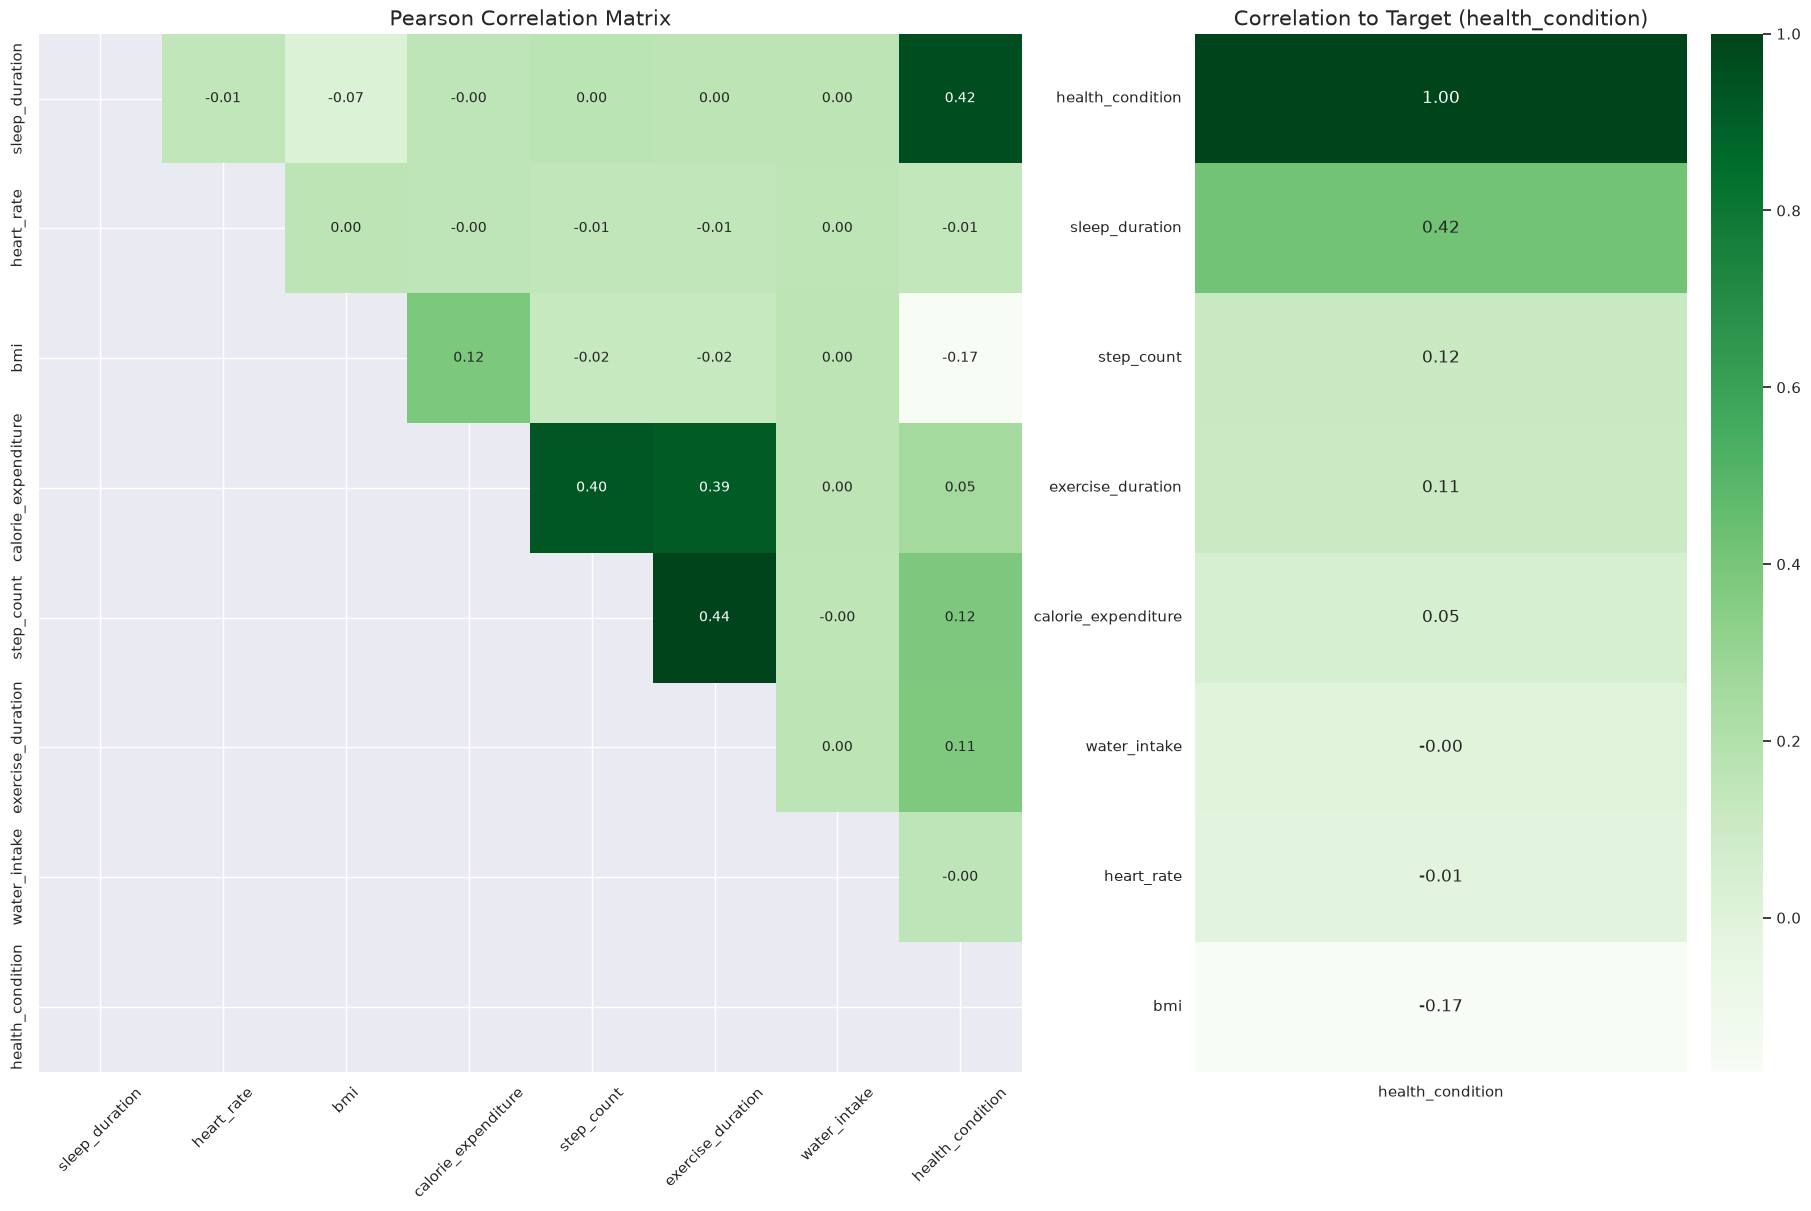

In [ ]:
def plot_target_correlation(
    data: pd.DataFrame,
    target: str,
    target_map:dict,
    fmt=".2f",
    cmap="Greens",
    figsize=(18, 12)
) -> None:
    copy = data.select_dtypes(include="number").drop("id", axis=1)
    copy[target] = data[target].map(target_map)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, 3)

    corr_hm_ax = fig.add_subplot(gs[0, :2])
    corr_target_ax = fig.add_subplot(gs[0, 2])
    mask = np.tril(copy.corr())

    corr_hm_ax.set_title("Pearson Correlation Matrix", size=15)
    corr_target_ax.set_title(f"Correlation to Target ({target})", size=15)

    sns.heatmap(copy.corr(), mask=mask, annot=True, fmt=fmt,
                cmap=cmap, ax=corr_hm_ax, cbar=False, annot_kws={"size": 10})

    sns.heatmap(copy.corr()[target].sort_values(ascending=False).to_frame(),
                annot=True, fmt=fmt, cmap=cmap, ax=corr_target_ax)

    corr_target_ax.set_yticklabels(corr_target_ax.get_yticklabels(), rotation=0)
    corr_hm_ax.set_xticklabels(corr_hm_ax.get_xticklabels(), rotation=45)

plot_target_correlation(train_data, "health_condition", {"unhealthy": 0, "at-risk": 1, "fit": 2})
plt.gca()

**Observations**: Confirms some previous observations from viewing the feature distributions from the target.

- `sleep_duration` and `bmi` show strong linear signals. This is consistent with the clean, monotonic separation in the box plots.
- `heart_rate` and `water_intake` are essentially uncorrelated, matching the fully-overlapping boxplots.
- `step_count` and `exercise_duration` show up as a weak-ish signal here, which *understates* their real value given what the boxplots showed (strong for separating "fit", weak for the other two classes).

## 3. Missing Data

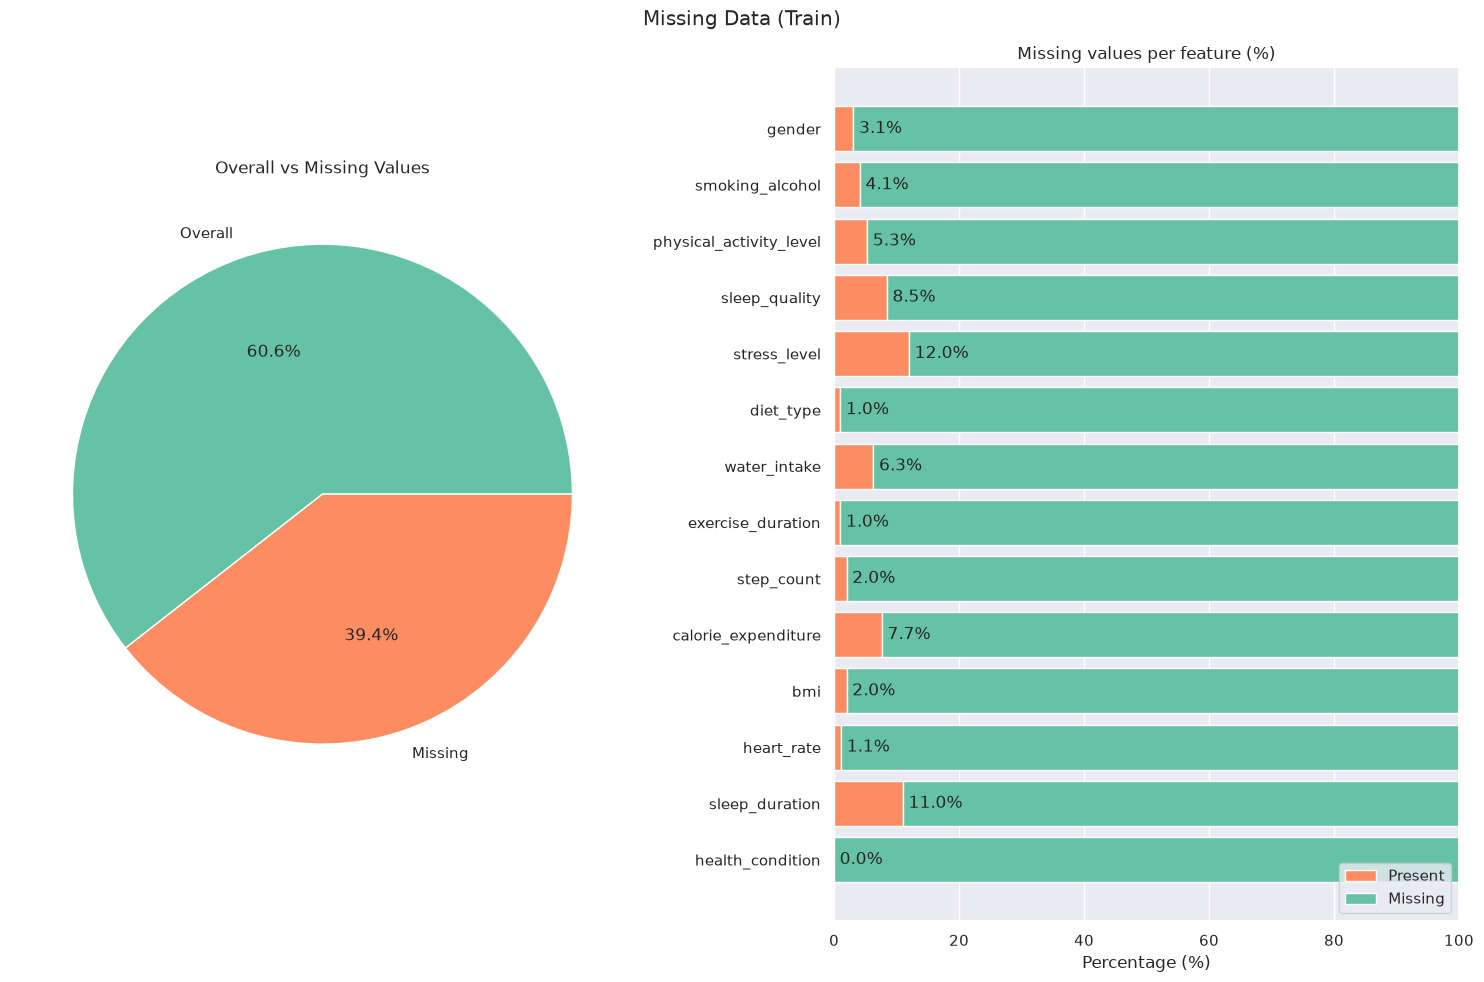

In [ ]:
def plot_missing_proportion(df:pd.DataFrame, subset:str, figsize=(15, 10)) -> None:
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    total = df.shape[0]
    missing = df.isna().sum().sum()

    axes[0].pie(x=[total, missing], labels=["Overall", "Missing"], autopct="%1.1f%%")
    axes[0].set_title("Overall vs Missing Values")

    missing_pct = df.drop("id", axis=1).isna().mean() * 100
    present_pct = 100 - missing_pct 

    p = axes[1].barh(missing_pct.index, missing_pct, color="#fc8d62", label="Present") #66c2a5
    axes[1].barh(missing_pct.index, present_pct, left=missing_pct, color="#66c2a5",label="Missing") #fc8d62
    axes[1].set_title("Missing values per feature (%)")
    axes[1].set_xlabel("Percentage (%)")
    axes[1].set_xlim(0, 100)
    axes[1].legend(loc="lower right")
    axes[1].bar_label(p, label_type="edge", fmt="%1.1f%%", padding=4)

    fig.suptitle(f"Missing Data ({subset})")
    fig.tight_layout()

plot_missing_proportion(train_data, "Train")
plt.gca()

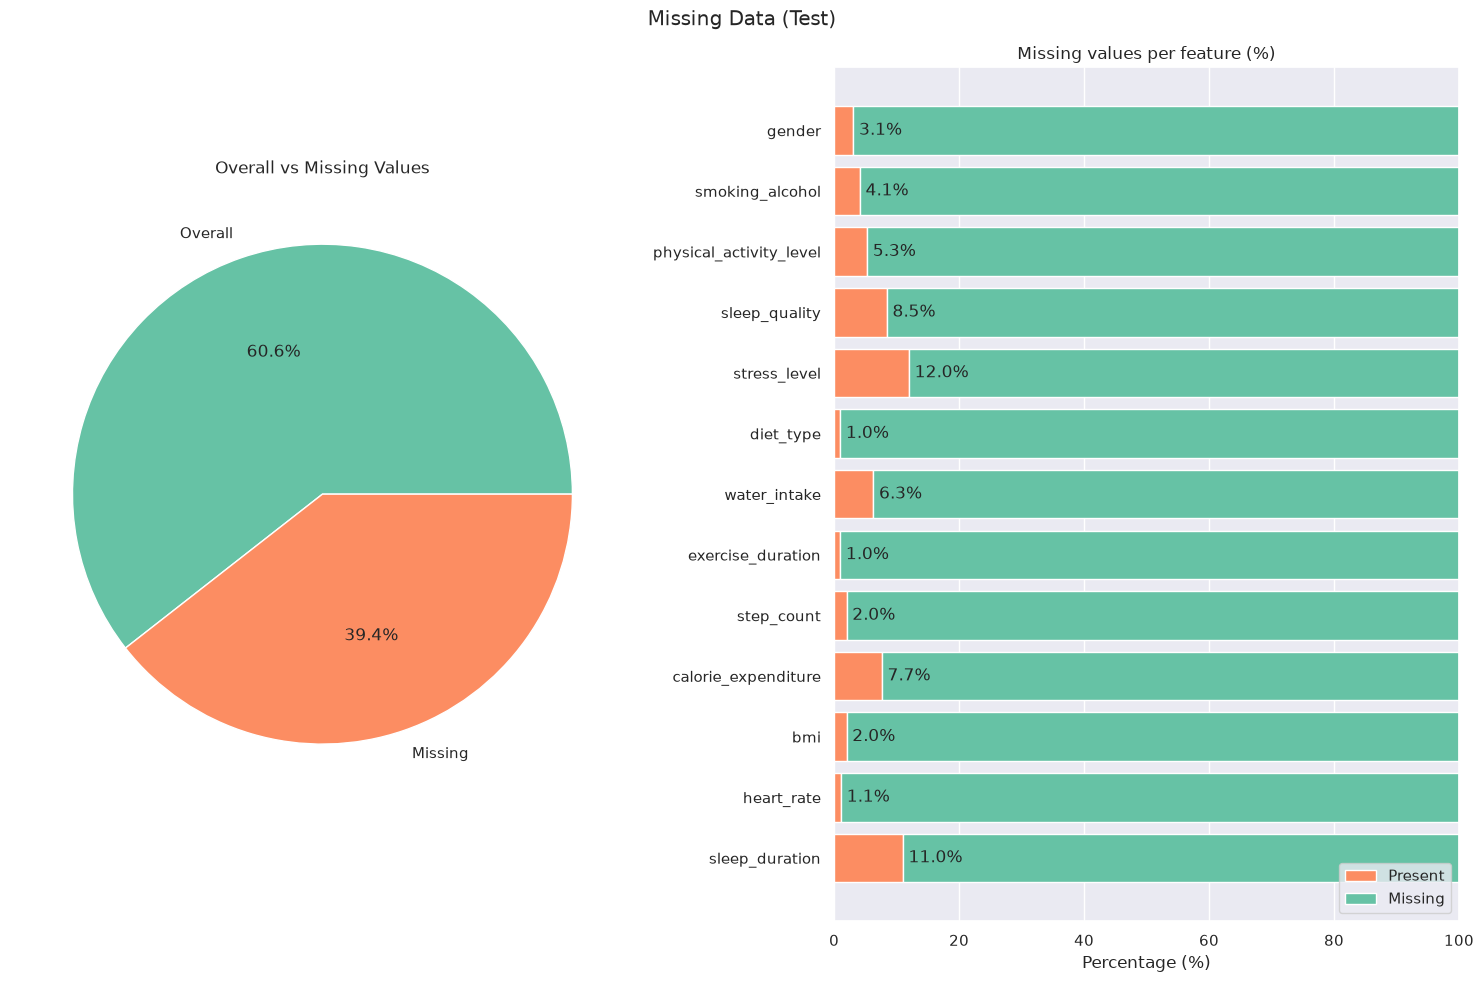

In [ ]:
plot_missing_proportion(test_data, "Test")
plt.gca()

**Observations**:
- Nearly half of the dataset consists of missing values with about **39.4%** missing and **60.6%** overall.
- Missingness is low in absolute terms, but scattered across nearly every feature.
- There's a clear split between subjective/self-reported fields and objective/logged fields.

Looking at which features have high missing rates:

- `stress_level`, `sleep_duration`, `sleep_quality`, `water_intake`, `calorie_expenditure`.

versus the lowest:

- `diet_type`, `exercise_duration`, `bmi`, `step_count`, `heart_rate`.

The high-missing group tends to be things people self-report or that require wearable/consistent tracking, while the low-missing group looks more like fields that are either directly measured or mandatory intake questions.

## 4. Train and test data distributions

### 4.1. Numerical features

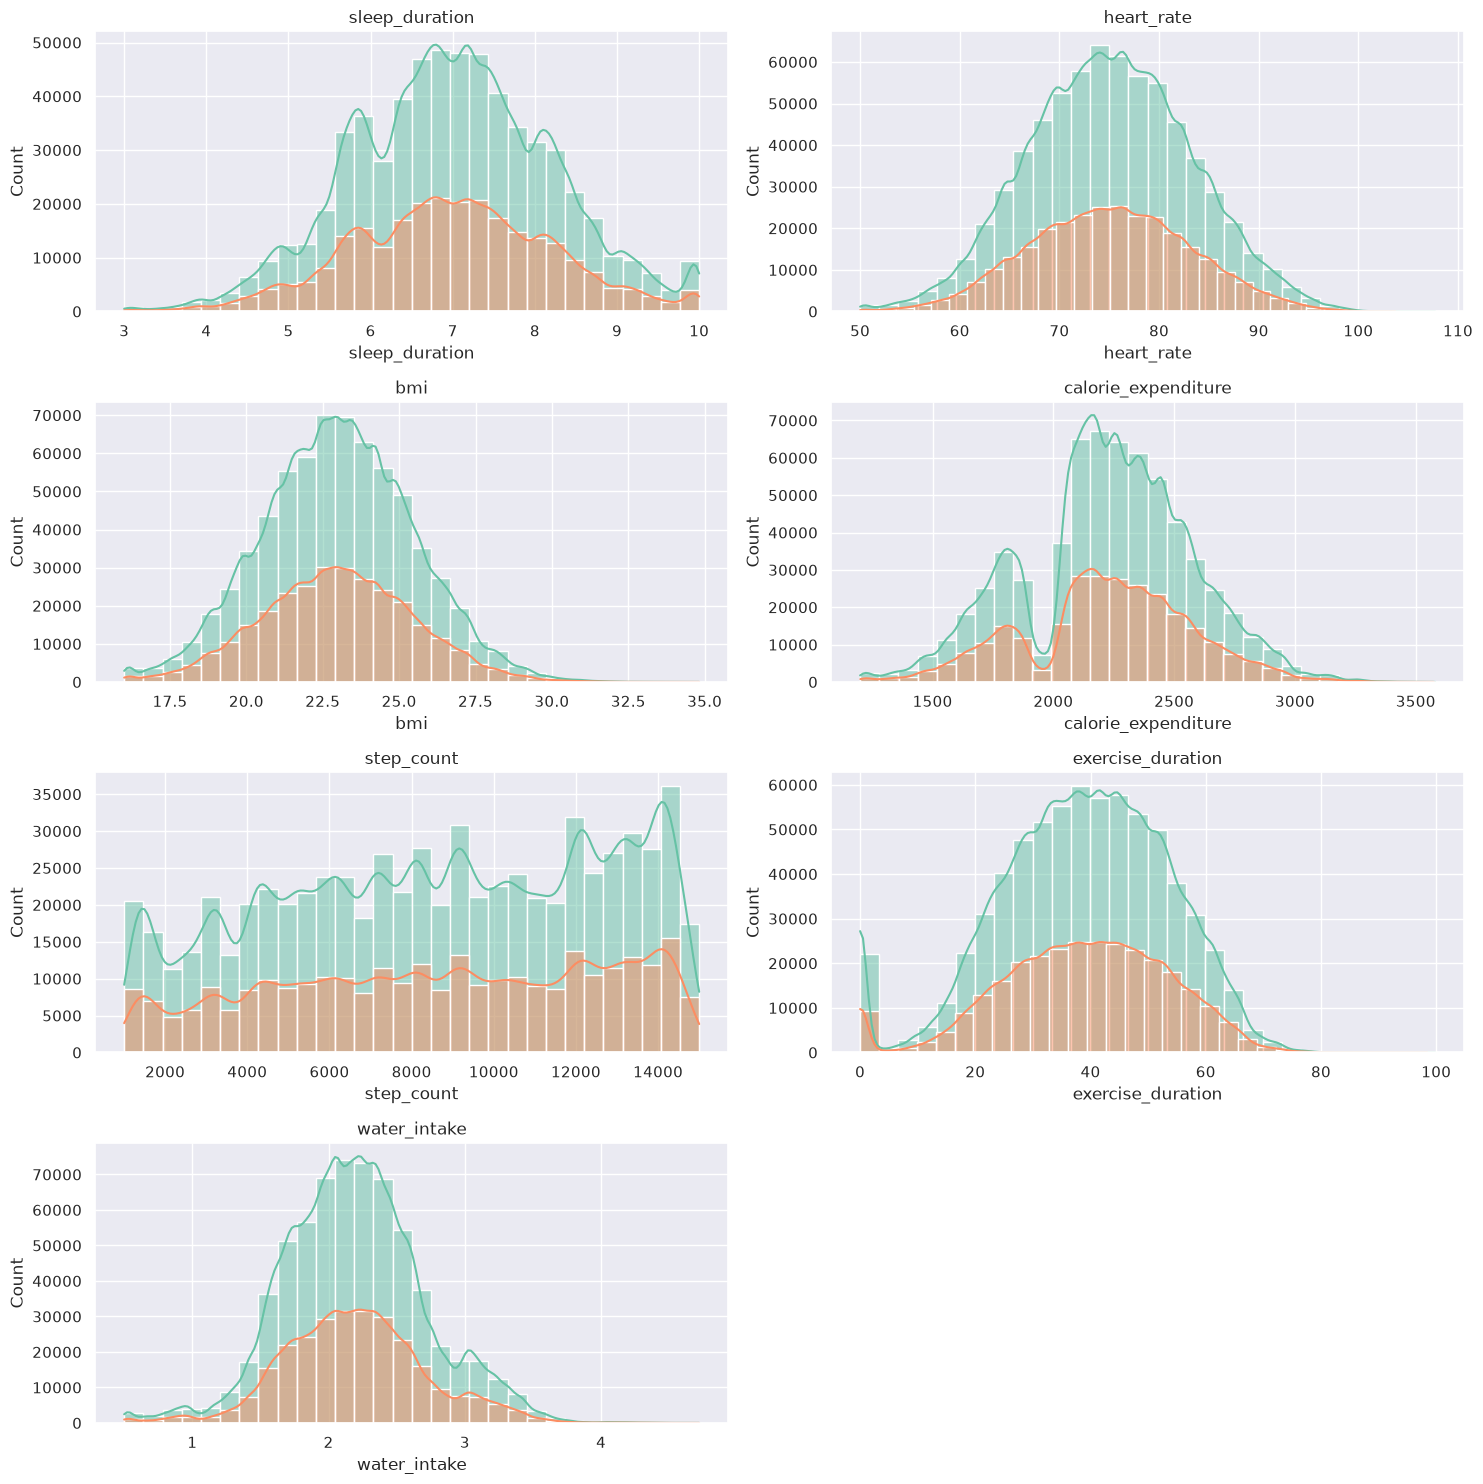

In [ ]:
def plot_num_feat_distribution(
    train_data:pd.DataFrame, 
    test_data:pd.DataFrame, 
    ncols:int,
    bins=30,
    figsize=(15, 15)
) -> None:
    train_num = train_data.select_dtypes(include="number")
    test_num = test_data.select_dtypes(include="number") 

    nfeats = train_num.columns.tolist()[1:]
    nrows = -(-len(nfeats ) // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, feat in enumerate(nfeats):
        row, col = i // ncols, i % ncols
        ax = axes[row, col] if nrows > 1 else axes[col]
        sns.histplot(data=train_num, x=feat, bins=bins, kde=True, ax=ax)
        sns.histplot(data=test_num, x=feat, bins=bins, kde=True, ax=ax)
        ax.set_title(f"{feat}")

    if len(nfeats) % ncols != 0: 
        for i in range(len(nfeats) % ncols, ncols):
            axes[-1, i].axis('off')

    fig.tight_layout()

plot_num_feat_distribution(train_data, test_data, 2)
plt.gca()

### 4.2. Categorical features

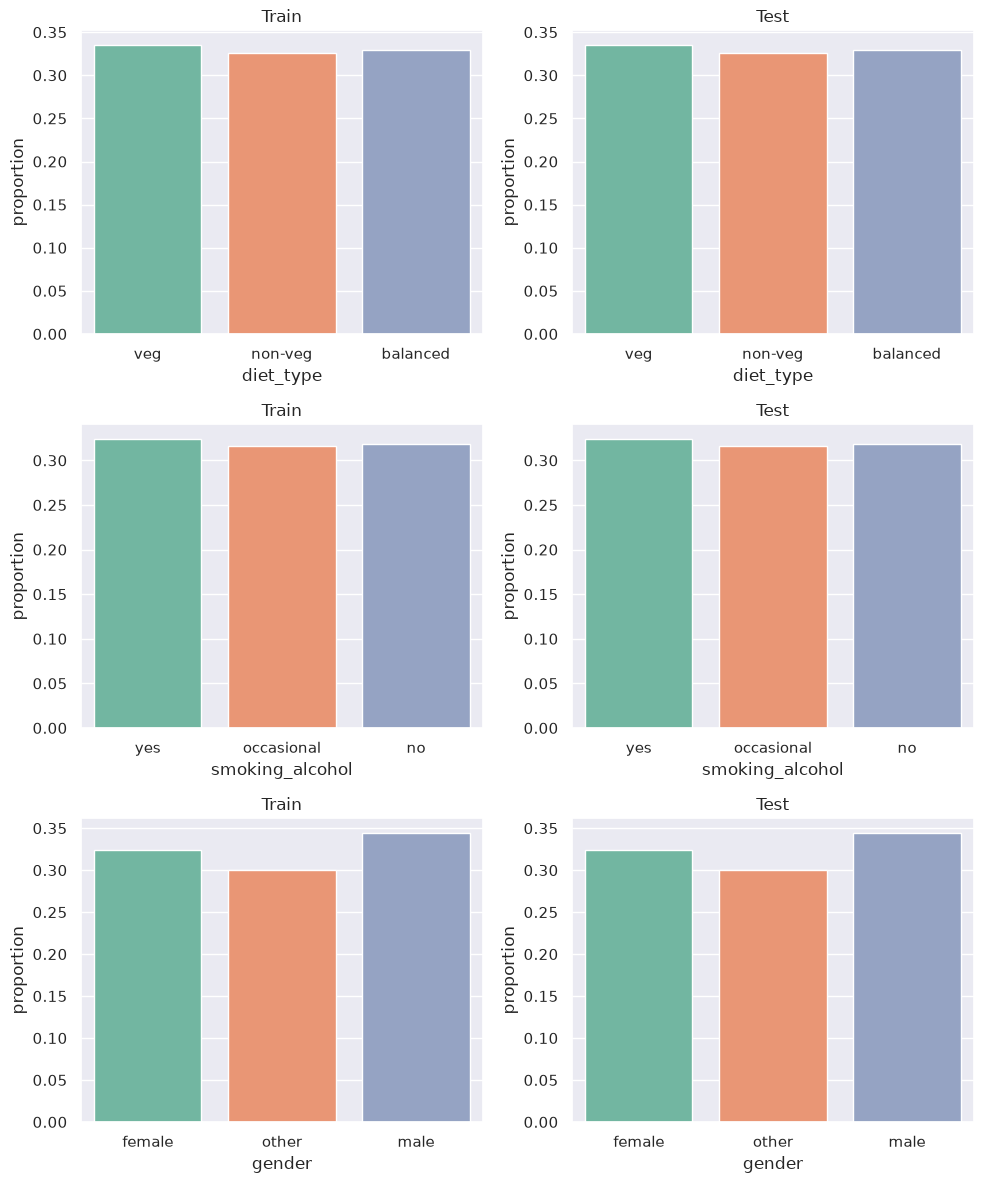

In [ ]:
def plot_cat_feat_distribution(
    train_data:pd.DataFrame,
    test_data:pd.DataFrame,
    target:str, 
    cat_cols:list,
    figsize=(10, 12)
) -> None:

    if target in cat_cols:
        cat_cols.remove(target)

    train_cat = train_data[cat_cols]
    test_cat = test_data[cat_cols]

    fig, axes = plt.subplots(nrows=len(cat_cols), ncols=2, figsize=figsize)

    for i, col in enumerate(cat_cols):
        sns.countplot(train_data, x=col, hue=col, stat="proportion", ax=axes[i, 0])
        sns.countplot(train_data, x=col, hue=col, stat="proportion", ax=axes[i, 1])

        axes[i, 0].set_title("Train")
        axes[i, 1].set_title("Test")

        axes[i, 0].get_legend().set_visible(False)
        axes[i, 1].get_legend().set_visible(False)

    fig.tight_layout()

plot_cat_feat_distribution(train_data, test_data, "health_condition", cat_cols)
plt.gca()

### 4.3. Ordinal features

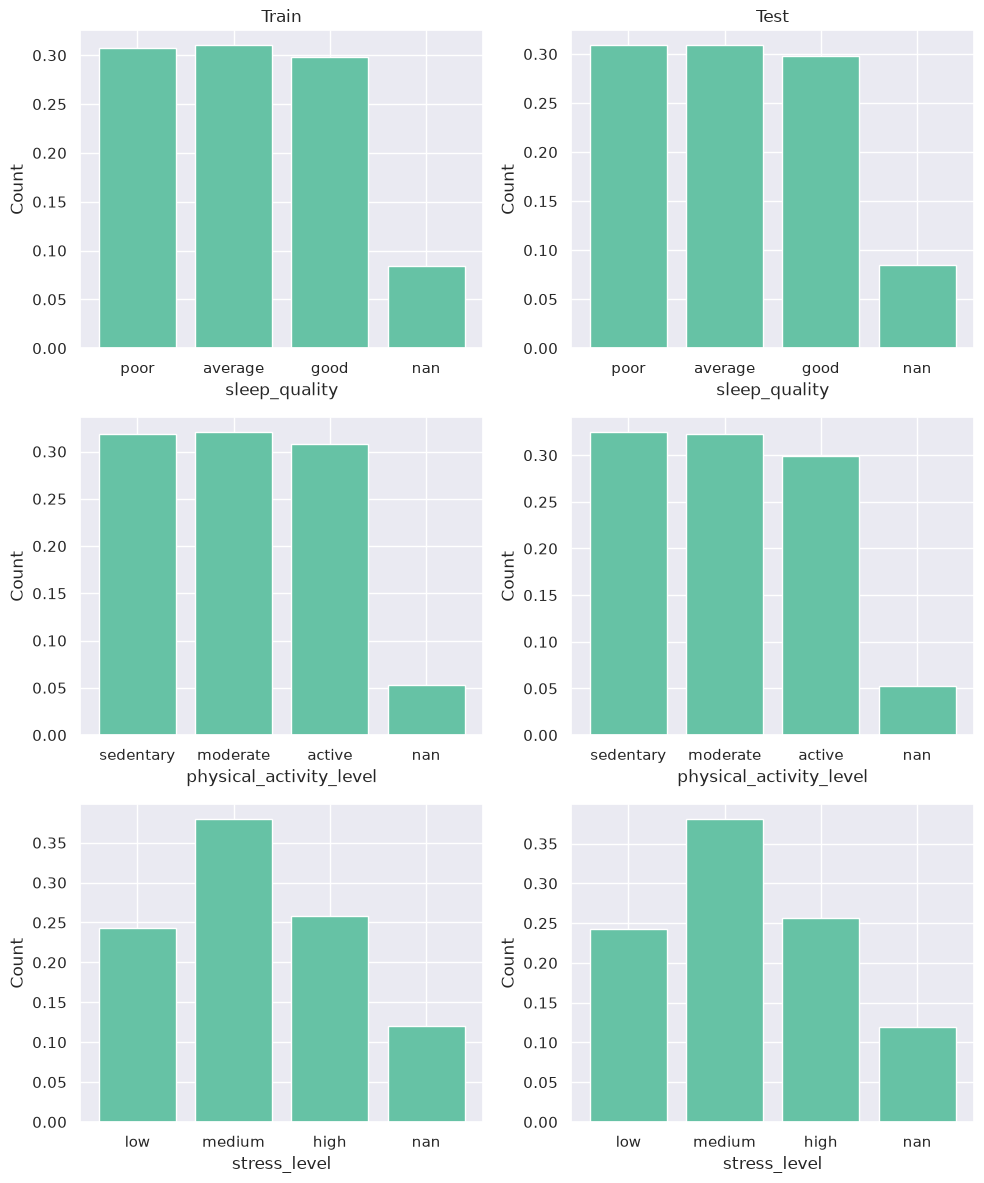

In [ ]:
import math

def create_cnt_map(df:pd.DataFrame, ord_mapping:dict[str, list[str]]):
    cnt_map = {}

    for col in list(ord_mapping.keys()):
        cnt_map[col] = dict.fromkeys(ord_mapping[col], 0)
        cnt_map[col]["nan"] = 0

        for cat in cnt_map[col]:
            if cat == "nan":
                cnt_map[col][cat] = df[col].isna().sum()
            else:
                cnt_map[col][cat] = df[df[col] == cat].shape[0]
            cnt_map[col][cat] *= 1.0
            cnt_map[col][cat] /= df.shape[0]

    return cnt_map

def plot_ordinal_feature_distribution(
    train_data:pd.DataFrame, 
    test_data:pd.DataFrame, 
    ord_mapping:dict[str, list[str]], 
    figsize=(10, 12)
) -> None:

    train_cnts = create_cnt_map(train_data, ord_mapping)
    test_cnts = create_cnt_map(test_data, ord_mapping)

    fig, axes = plt.subplots(nrows=len(ord_cols), ncols=2, figsize=figsize)
    fig.tight_layout()

    axes[0, 0].set_title("Train")
    axes[0, 1].set_title("Test")

    for i, col in enumerate(list(ord_mapping.keys())):
        axes[i, 0].bar(x=list(train_cnts[col].keys()), height=list(train_cnts[col].values()))
        axes[i, 1].bar(x=list(test_cnts[col].keys()), height=list(test_cnts[col].values()))

        axes[i, 0].set_xlabel(f"{col}")
        axes[i, 1].set_xlabel(f"{col}")

        axes[i, 0].set_ylabel("Count")
        axes[i, 1].set_ylabel("Count")

    fig.tight_layout()

    return train_cnts, test_cnts

ord_mapping = dict.fromkeys(ord_cols, [])

ord_mapping["sleep_quality"] = ["poor", "average", "good"]
ord_mapping["physical_activity_level"] = ["sedentary", "moderate", "active"]
ord_mapping["stress_level"] = ["low", "medium", "high"]

plot_ordinal_feature_distribution(train_data, test_data, ord_mapping)
plt.gca()

**Observations**: No visible distribution drift between train and test data.